Before 1370: 0 | Numeric years: 795191 | Range: 1371 - 1403


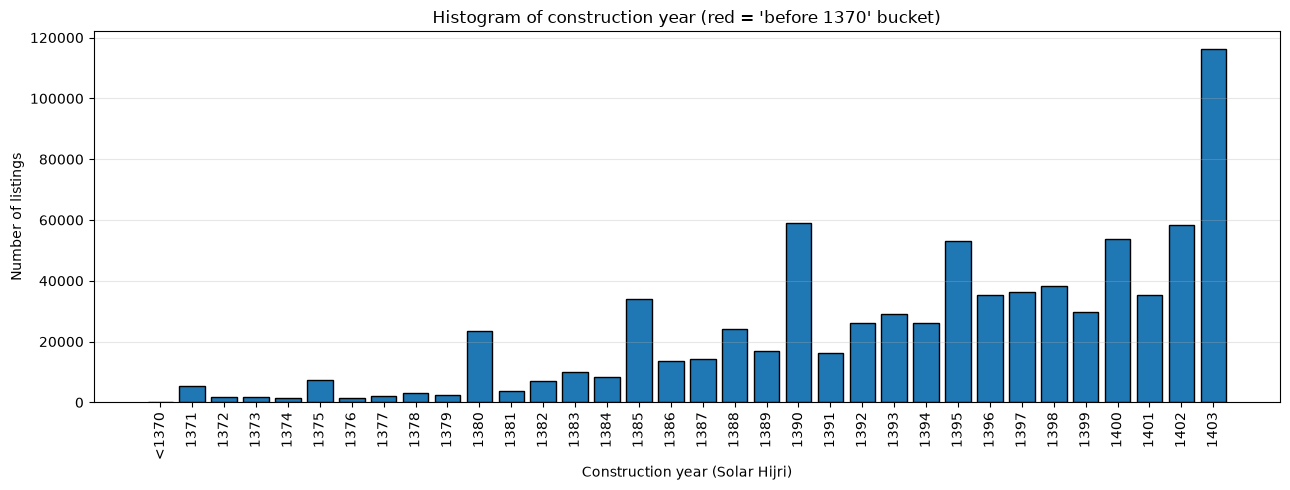

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\vision\Desktop\bootcamp_p1\Divar.csv", usecols=["construction_year"])


to_en = str.maketrans("۰۱۲۳۴۵۶۷۸۹", "0123456789")
s = df["construction_year"].dropna().astype(str).str.strip().str.translate(to_en)

old_count = s.str.contains("before").sum()

years = pd.to_numeric(s[~s.str.contains("before")], errors="coerce").dropna().astype(int)
counts = years.value_counts().sort_index()
print("Before 1370:", old_count, "| Numeric years:", len(years), "| Range:", counts.index.min(), "-", counts.index.max())

labels = ["<1370"] + [str(y) for y in counts.index]
values = [old_count] + counts.tolist()

fig, ax = plt.subplots(figsize=(13, 5))
colors = ["tab:red"] + ["tab:blue"] * len(counts)
ax.bar(range(len(values)), values, color=colors, edgecolor="black")
ax.set_xticks(range(len(values)))
ax.set_xticklabels(labels, rotation=90)
ax.set_xlabel("Construction year (Solar Hijri)")
ax.set_ylabel("Number of listings")
ax.set_title("Histogram of construction year (red = 'before 1370' bucket)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("construction_year_hist.png", dpi=150)
plt.show()

Listings with valid coordinates: 655589

Top cities by number of listings:
city_slug
tehran               143082
mashhad               37357
karaj                 36037
isfahan               24772
shiraz                19947
tabriz                16876
andisheh-new-town     15405
rasht                 12352
kermanshah            10849
qom                    9403
Name: count, dtype: int64

Top neighborhoods by number of listings:
city_slug  neighborhood_slug
tehran     poonak               3817
mashhad    elahiyehblvd         3086
tehran     west-tehranpars      2991
mashhad    ghasemabad           2911
tehran     saadat-abad          2836
karaj      marlik               2612
tehran     jeyhoun              2555
           sarsabil             2465
karaj      gohardasht           2437
tehran     chitgar-lake         2271
dtype: int64


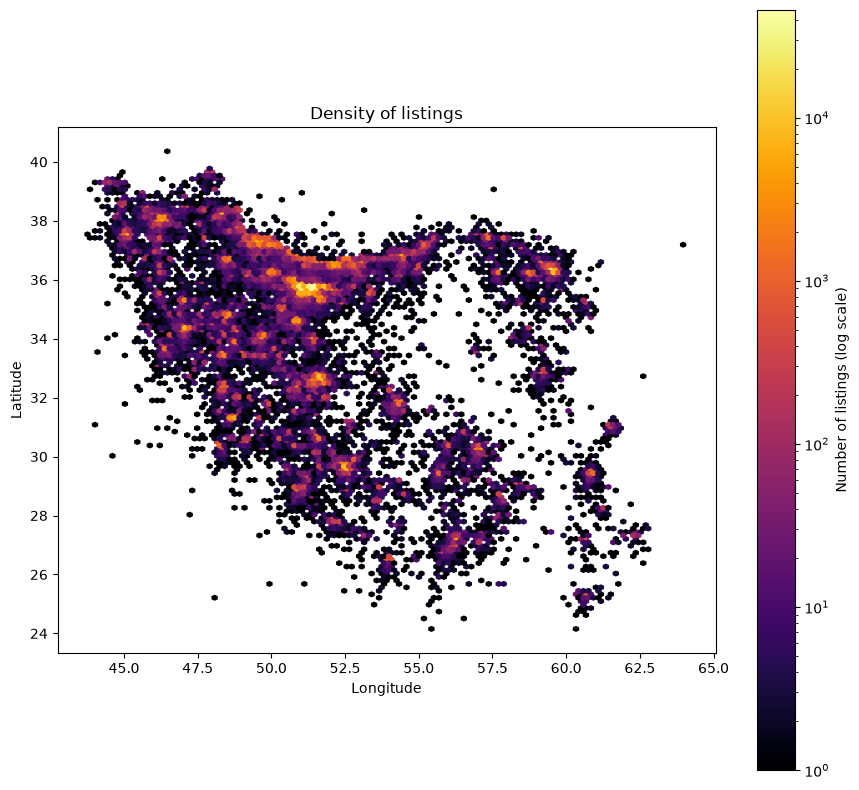

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

cols = ["location_latitude", "location_longitude", "city_slug", "neighborhood_slug"]
df = pd.read_csv(r"C:\Users\vision\Desktop\bootcamp_p1\Divar.csv", usecols=cols)


to_en = str.maketrans("۰۱۲۳۴۵۶۷۸۹", "0123456789")
def to_num(col):
    s = col.astype(str).str.translate(to_en).str.replace("٫", ".", regex=False)
    return pd.to_numeric(s, errors="coerce")

df["lat"] = to_num(df["location_latitude"])
df["lon"] = to_num(df["location_longitude"])


df = df.dropna(subset=["lat", "lon"])
df = df[df["lat"].between(24, 40.6) & df["lon"].between(43.5, 64.1)]
print("Listings with valid coordinates:", len(df))


print("\nTop cities by number of listings:")
print(df["city_slug"].value_counts().head(10))
print("\nTop neighborhoods by number of listings:")
print(df.groupby(["city_slug", "neighborhood_slug"]).size().sort_values(ascending=False).head(10))

plt.figure(figsize=(9, 8))
hb = plt.hexbin(df["lon"], df["lat"], gridsize=120, bins="log", cmap="inferno", mincnt=1)
plt.colorbar(hb, label="Number of listings (log scale)")
plt.gca().set_aspect("equal")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Density of listings")
plt.tight_layout()
plt.savefig("listings_hexbin.png", dpi=150)
plt.show()

try:
    import folium
    from folium.plugins import HeatMap
    d = df.sample(min(len(df), 200_000), random_state=42)   # For keeping it lightweight
    m = folium.Map(location=[32.5, 53], zoom_start=5, tiles="OpenStreetMap")
    HeatMap(d[["lat", "lon"]].values.tolist(), radius=8, blur=12, min_opacity=0.3).add_to(m)
    m.save("listings_heatmap.html")
except ImportError:
    print("folium is not installed: pip install folium")